In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

pd.set_option('display.max_columns', None)
np.random.seed(42)

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
tf.random.set_seed(42)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2η εργασία/fda_adverse_events_2015_2026_CLEAN.csv')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (528000, 30)


,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,is_disabling,reactions,primary_reaction,reaction_outcomes,patient_recovered,num_reactions,suspect_drug,brand_name,drug_route,drug_indication,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,False,Breast pain; Asthma; Cough; Drug ineffective,Breast pain,Unknown; Not Recovered; Recovered; Recovering,False,4,FLUTICASONE PROPIONATE AND SALMETEROL XINAFOATE,ADVAIR HFA,Unknown,Unknown,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,False,Device issue; Scar; Uterine perforation; Abort...,Device issue,Unknown,False,10,LEVONORGESTREL,MIRENA,15.0,Contraception,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,False,Faecal incontinence; Neck surgery; Drug effect...,Faecal incontinence,Not Recovered; Recovered,False,6,ADALIMUMAB,HUMIRA,Unknown,Crohn^S Disease,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055


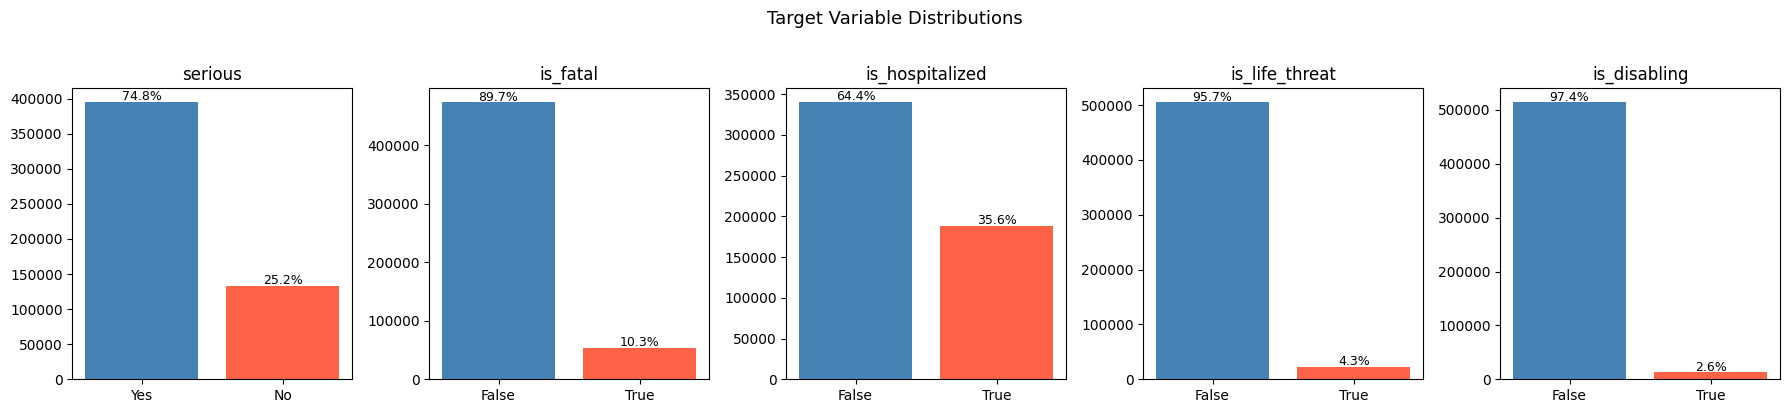

In [ ]:
targets = ['serious', 'is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, targets):
    counts = df[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color=['steelblue', 'tomato'])
    ax.set_title(col)
    ax.set_xlabel('')
    for i, v in enumerate(counts.values):
        ax.text(i, v + len(df)*0.005, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)
plt.suptitle('Target Variable Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('targets.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Pct (%)', ascending=False)
print(missing_df)

                   Missing  Pct (%)
patient_weight_kg   379923    71.96
serious_flags       301106    57.03
patient_age_years   151509    28.69


In [ ]:
# Drop & Handle Missing
df = df.drop(columns=['patient_weight_kg', 'serious_flags'])

print(f"Shape μετά το drop: {df.shape}")
print(f"\nΕναπομείναντα missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape μετά το drop: (528000, 28)

Εναπομείναντα missing values:
patient_age_years    151509
dtype: int64


count    9828.000000
mean        5.402116
std         9.217148
min         1.000000
25%         1.000000
50%         1.000000
75%         4.000000
max        44.000000
Name: quarter, dtype: float64

Φάρμακα με 20+ quarters: 809
Φάρμακα με 40+ quarters: 239


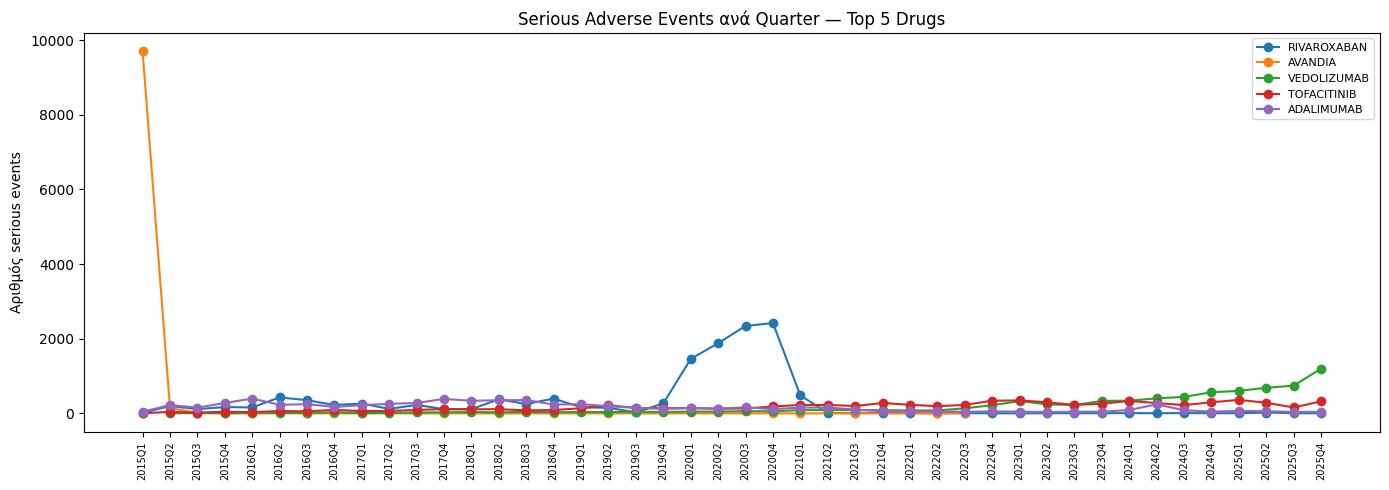

In [ ]:
# Serious Events per Drug per Quarter
df['is_serious'] = (df['serious'] == 'Yes').astype(int)

serious_ts = (df.groupby(['suspect_drug', 'quarter'])['is_serious']
               .sum()
               .reset_index(name='serious_count'))

# Πόσα quarters έχει κάθε φάρμακο;
quarters_per_drug = serious_ts.groupby('suspect_drug')['quarter'].count()
print(quarters_per_drug.describe())
print(f"\nΦάρμακα με 20+ quarters: {(quarters_per_drug >= 20).sum()}")
print(f"Φάρμακα με 40+ quarters: {(quarters_per_drug >= 40).sum()}")

# Top 5 φάρμακα για visualization
top_drugs = (serious_ts.groupby('suspect_drug')['serious_count']
             .sum().nlargest(5).index.tolist())

plt.figure(figsize=(14, 5))
for drug in top_drugs:
    data = serious_ts[serious_ts['suspect_drug'] == drug]
    plt.plot(data['quarter'], data['serious_count'], marker='o', label=drug[:30], linewidth=1.5)
plt.xticks(rotation=90, fontsize=7)
plt.title('Serious Adverse Events ανά Quarter — Top 5 Drugs')
plt.ylabel('Αριθμός serious events')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('serious_ts.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  Φιλτράρισμα & Pivot σε πλήρη χρονοσειρά
MIN_QUARTERS = 40

# Κρατάμε μόνο φάρμακα με 40+ quarters
drugs_enough = quarters_per_drug[quarters_per_drug >= MIN_QUARTERS].index
serious_filtered = serious_ts[serious_ts['suspect_drug'].isin(drugs_enough)]

print(f"Φάρμακα που κρατάμε: {len(drugs_enough)}")
print(f"Γραμμές: {len(serious_filtered)}")

# Pivot: γραμμές = quarters, στήλες = φάρμακα
pivot = serious_filtered.pivot_table(
    index='quarter', columns='suspect_drug',
    values='serious_count', fill_value=0
)

pivot = pivot.sort_index()

print(f"\nPivot shape: {pivot.shape}")

print(f"\nΠρώτες 5 γραμμές (5 πρώτα φάρμακα):")
print(pivot.iloc[:5, :5])

Φάρμακα που κρατάμε: 239
Γραμμές: 10214

Pivot shape: (44, 239)

Πρώτες 5 γραμμές (5 πρώτα φάρμακα):
suspect_drug  ABATACEPT  ABIRATERONE ACETATE  \
quarter                                        
2015Q1              3.0                  0.0   
2015Q2             56.0                  7.0   
2015Q3             66.0                  5.0   
2015Q4             89.0                 12.0   
2016Q1             65.0                 13.0   

suspect_drug  ACETAMINOPHEN; ACETAMINOPHEN 500MG; ACETAMINOPHEN TABLET EXTENDED RELEASE; PAIN RELIEVER  \
quarter                                                                                                  
2015Q1                                                      1.0                                          
2015Q2                                                      2.0                                          
2015Q3                                                      3.0                                          
2015Q4                          

In [ ]:
# Sliding Windows + Per-Drug Split
WINDOW = 8
TRAIN_RATIO = 0.8
scalers = {}
X_train_list, y_train_list = [], []
X_test_list,  y_test_list  = [], []

for drug in pivot.columns:
    series = pivot[drug].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    series_scaled = scaler.fit_transform(series)
    scalers[drug] = scaler

    X_drug, y_drug = [], []
    for i in range(len(series_scaled) - WINDOW):
        X_drug.append(series_scaled[i:i+WINDOW])
        y_drug.append(series_scaled[i+WINDOW])

    X_drug = np.array(X_drug)
    y_drug = np.array(y_drug)

    split_drug = int(len(X_drug) * TRAIN_RATIO)
    X_train_list.append(X_drug[:split_drug])
    y_train_list.append(y_drug[:split_drug])
    X_test_list.append(X_drug[split_drug:])
    y_test_list.append(y_drug[split_drug:])

X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)
X_test  = np.concatenate(X_test_list)
y_test  = np.concatenate(y_test_list)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")


X_train: (6692, 8, 1)
X_test:  (1912, 8, 1)


In [ ]:
def build_deep_lstm():
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(WINDOW, 1)),
        Dropout(0.2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_deep_lstm()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 8, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 8, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,929 (503.63 KB)

 Trainable params: 128,929 (503.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, min_delta=0.0001)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.0477 - mae: 0.1559 - val_loss: 0.0381 - val_mae: 0.1409
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0395 - mae: 0.1415 - val_loss: 0.0380 - val_mae: 0.1382
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0375 - mae: 0.1365 - val_loss: 0.0370 - val_mae: 0.1358
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0368 - mae: 0.1346 - val_loss: 0.0358 - val_mae: 0.1330
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0360 - mae: 0.1322 - val_loss: 0.0356 - val_mae: 0.1301
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0352 - mae: 0.1299 - val_loss: 0.0346 - val_mae: 0.1299
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 0.0350 - mae: 0.1294 - val_loss: 0.0345 - val_mae: 0.1286
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0344 - mae: 0.1279 - val_loss: 0.0343 - val_mae: 0.1297
Epoch 9/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - l

In [ ]:
# Αξιολόγηση στο Test Set
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Mean Squared Error:  {test_loss:.3f}")
print(f"Test Mean Average Error:  {test_mae:.3f}")

Test Mean Squared Error:  0.046
Test Mean Average Error:  0.146


In [ ]:
y_pred = model.predict(X_test)

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


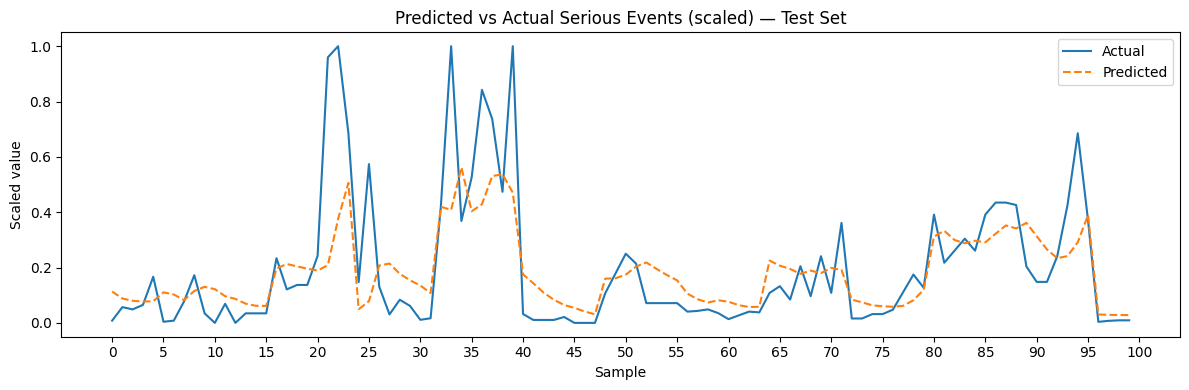

In [ ]:
# Visualization: Predicted vs Actual (scaled)
plt.figure(figsize=(12, 4))
plt.plot(y_test[:100], label='Actual', linewidth=1.5)
plt.plot(y_pred[:100], label='Predicted', linewidth=1.5, linestyle='--')
plt.title('Predicted vs Actual Serious Events (scaled) — Test Set')
plt.xlabel('Sample')
plt.ylabel('Scaled value')
plt.xticks(np.arange(0, 101, 5))
plt.legend()
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

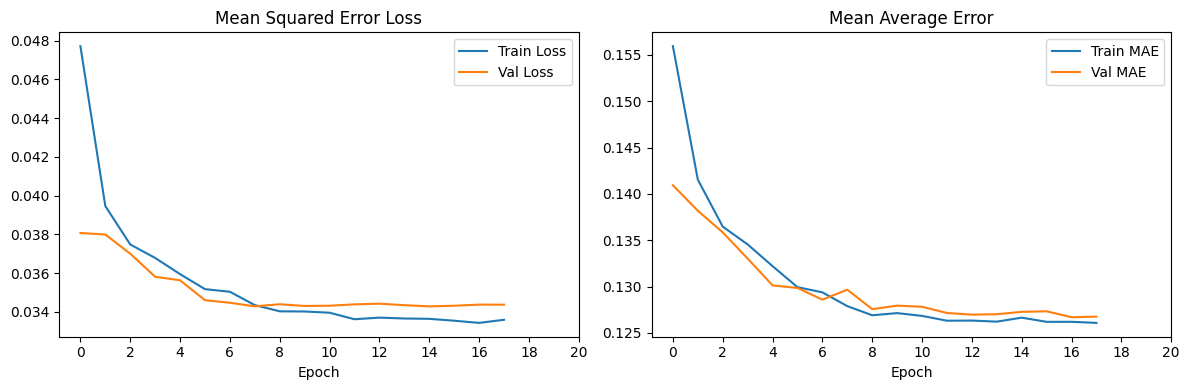

In [ ]:
# Training History
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xticks(np.arange(0, 22, 2))
axes[0].set_title('Mean Squared Error Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_xticks(np.arange(0, 22, 2))
axes[1].set_title('Mean Average Error')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Baseline: Naive Forecast
# "Το επόμενο quarter = το τελευταίο γνωστό quarter"
naive_pred = X_test[:, -1, :]  # τελευταία τιμή κάθε sequence

naive_mse = np.mean((naive_pred - y_test) ** 2)
naive_mae = np.mean(np.abs(naive_pred - y_test))

# Moving Average Baseline (window=4 quarters)
ma_pred = X_test[:, -4:, 0].mean(axis=1, keepdims=True)

ma_mse = np.mean((ma_pred - y_test) ** 2)
ma_mae = np.mean(np.abs(ma_pred - y_test))

# Ενημερωμένος πίνακας σύγκρισης
print(f"{'Μοντέλο':<25} {'MSE':>8} {'MAE':>8}")
print("-" * 43)
print(f"{'Naive Forecast':<25} {naive_mse:.2%} {naive_mae:.2%}")
print(f"{'Moving Average (4Q)':<25} {ma_mse:.2%} {ma_mae:.2%}")
print(f"{'Deep LSTM':<25} {test_loss:.2%} {test_mae:.2%}")
print("-" * 43)
print(f"\nΒελτίωση vs Naive  — MSE: {(naive_mse - test_loss) / naive_mse * 100:.1f}%, MAE: {(naive_mae - test_mae) / naive_mae * 100:.1f}%")
print(f"Βελτίωση vs MA     — MSE: {(ma_mse - test_loss) / ma_mse * 100:.1f}%, MAE: {(ma_mae - test_mae) / ma_mae * 100:.1f}%")

Μοντέλο                        MSE      MAE
-------------------------------------------
Naive Forecast            6.52% 16.63%
Moving Average (4Q)       4.98% 15.16%
Deep LSTM                 4.59% 14.61%
-------------------------------------------

Βελτίωση vs Naive  — MSE: 29.6%, MAE: 12.1%
Βελτίωση vs MA     — MSE: 7.8%, MAE: 3.7%


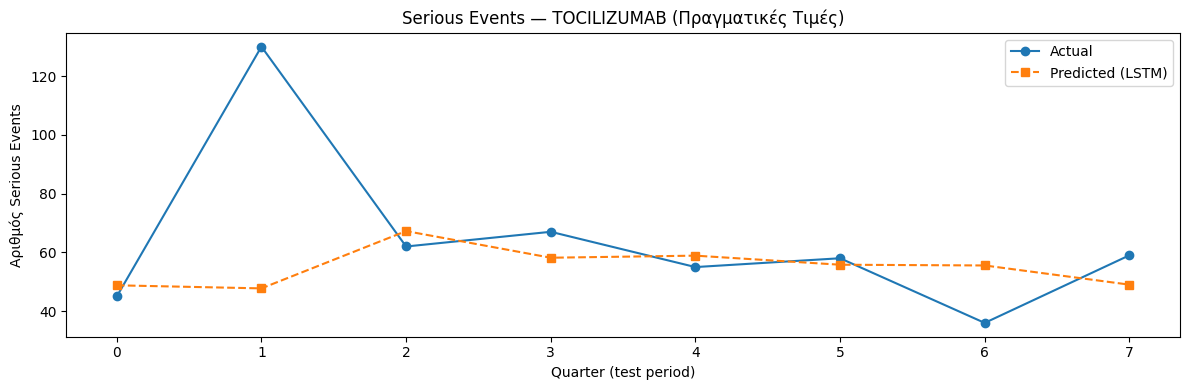

Μέση πραγματική τιμή: 64 events/quarter
Μέσο απόλυτο σφάλμα: 17 events/quarter


In [ ]:
# Inverse Transform — σωστό για per-drug split
example_drug = 'TOCILIZUMAB'

# Ξαναχτίζουμε τα windows για αυτό το φάρμακο
series = pivot[example_drug].values.reshape(-1, 1)
scaler_drug = scalers[example_drug]
series_scaled = scaler_drug.transform(series)  # χρήση ήδη fitted scaler

X_drug, y_drug = [], []
for i in range(len(series_scaled) - WINDOW):
    X_drug.append(series_scaled[i:i+WINDOW])
    y_drug.append(series_scaled[i+WINDOW])

X_drug = np.array(X_drug)
y_drug = np.array(y_drug)

split_drug = int(len(X_drug) * TRAIN_RATIO)
X_drug_test = X_drug[split_drug:]
y_drug_test = y_drug[split_drug:]

# Πρόβλεψη
y_pred_drug = model.predict(X_drug_test, verbose=0)

# Inverse transform → πραγματικές τιμές
y_actual_real = scaler_drug.inverse_transform(y_drug_test)
y_pred_real   = scaler_drug.inverse_transform(y_pred_drug)

plt.figure(figsize=(12, 4))
plt.plot(y_actual_real, label='Actual', marker='o', linewidth=1.5)
plt.plot(y_pred_real, label='Predicted (LSTM)', marker='s', linewidth=1.5, linestyle='--')
plt.title(f'Serious Events — {example_drug} (Πραγματικές Τιμές)')
plt.xlabel('Quarter (test period)')
plt.ylabel('Αριθμός Serious Events')
plt.legend()
plt.tight_layout()
plt.savefig('inverse_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Μέση πραγματική τιμή: {y_actual_real.mean():.0f} events/quarter")
print(f"Μέσο απόλυτο σφάλμα: {np.abs(y_actual_real - y_pred_real).mean():.0f} events/quarter")

In [ ]:
#  EXTENDED MODEL: Per-Reaction Analysis

reaction_categories = {
    'cardiac':    ['cardiac', 'myocardial', 'heart', 'arrhythmia', 'atrial'],
    'infection':  ['infection', 'sepsis', 'pneumonia', 'bacterial', 'viral'],
    'neuro':      ['stroke', 'seizure', 'neuropathy', 'encephalopathy', 'headache'],
    'gastro':     ['hepatic', 'liver', 'gastrointestinal', 'colitis', 'diarrhoea']
}

def categorize_reaction(reaction_text):
    if pd.isna(reaction_text):
        return 'other'
    reaction_lower = str(reaction_text).lower()
    for category, keywords in reaction_categories.items():
        if any(kw in reaction_lower for kw in keywords):
            return category
    return 'other'

df['reaction_category'] = df['reactions'].apply(categorize_reaction)
print(df['reaction_category'].value_counts())

reaction_category
other        376453
infection     52917
gastro        41926
cardiac       31711
neuro         24993
Name: count, dtype: int64


In [ ]:
serious_multi = (df[df['serious'] == 'Yes']
                 .groupby(['suspect_drug', 'quarter', 'reaction_category'])
                 .size()
                 .reset_index(name='serious_count'))

# Κρατάμε τα ίδια 239 φάρμακα
serious_multi = serious_multi[serious_multi['suspect_drug'].isin(drugs_enough)]

pivot_multi = serious_multi.pivot_table(
    index='quarter',
    columns=['suspect_drug', 'reaction_category'],
    values='serious_count',
    fill_value=0
).sort_index()

print(f"Pivot shape: {pivot_multi.shape}")

Pivot shape: (44, 1193)


In [ ]:
WINDOW_M = 8
TRAIN_RATIO_M = 0.8
all_categories = sorted(list(reaction_categories.keys()) + ['other'])
N_FEATURES = len(all_categories)  # 5
scalers_multi = {}
X_train_m, y_train_m = [], []
X_test_m,  y_test_m  = [], []

for drug in drugs_enough:
    try:
        drug_data = pivot_multi[drug].reindex(columns=all_categories, fill_value=0)
        series = drug_data.values  # (44, 5) — πάντα 5 features
    except KeyError:
        continue

    scaler_m = MinMaxScaler()
    series_scaled = scaler_m.fit_transform(series)
    scalers_multi[drug] = scaler_m

    X_drug_m, y_drug_m = [], []
    for i in range(len(series_scaled) - WINDOW_M):
        X_drug_m.append(series_scaled[i:i+WINDOW_M])
        y_drug_m.append(series_scaled[i+WINDOW_M])

    X_drug_m = np.array(X_drug_m)
    y_drug_m = np.array(y_drug_m)

    split_m = int(len(X_drug_m) * TRAIN_RATIO_M)
    X_train_m.append(X_drug_m[:split_m])
    y_train_m.append(y_drug_m[:split_m])
    X_test_m.append(X_drug_m[split_m:])
    y_test_m.append(y_drug_m[split_m:])

X_train_m = np.concatenate(X_train_m)
y_train_m = np.concatenate(y_train_m)
X_test_m  = np.concatenate(X_test_m)
y_test_m  = np.concatenate(y_test_m)

print(f"X_train_m: {X_train_m.shape}")
print(f"X_test_m:  {X_test_m.shape}")
print(f"N_FEATURES: {N_FEATURES}")

X_train_m: (6692, 8, 5)
X_test_m:  (1912, 8, 5)
N_FEATURES: 5


In [ ]:
def build_multi_lstm():
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(WINDOW_M, N_FEATURES)),
        Dropout(0.2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(N_FEATURES)  # 5 outputs
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_multi = build_multi_lstm()
model_multi.summary()

early_stop_m = EarlyStopping(monitor='val_loss', patience=10,
                              restore_best_weights=True, min_delta=0.0001)

history_multi = model_multi.fit(
    X_train_m, y_train_m,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_m],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 8, 128)         │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 8, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,045 (511.89 KB)

 Trainable params: 131,045 (511.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - loss: 0.0631 - mae: 0.1805 - val_loss: 0.0596 - val_mae: 0.1798
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0570 - mae: 0.1750 - val_loss: 0.0587 - val_mae: 0.1729
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0560 - mae: 0.1727 - val_loss: 0.0575 - val_mae: 0.1724
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.0553 - mae: 0.1708 - val_loss: 0.0568 - val_mae: 0.1719
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0547 - mae: 0.1697 - val_loss: 0.0566 - val_mae: 0.1709
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0542 - mae: 0.1687 - val_loss: 0.0562 - val_mae: 0.1688
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.0541 - mae: 0.1681 - val_loss: 0.0560 - val_mae: 0.1688
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0538 - mae: 0.1674 - val_loss: 0.0561 - val_mae: 0.1698
Epoch 9/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - l

In [ ]:
test_loss_m, test_mae_m = model_multi.evaluate(X_test_m, y_test_m, verbose=0)
print(f"Multi-Reaction LSTM — Test MSE: {test_loss_m:.2%}, MAE: {test_mae_m:.2%}")

# Σύγκριση με base model
print(f"\n{'Μοντέλο':<30} {'MSE':>8} {'MAE':>8}")
print(f"{'Base LSTM (serious only)':<30} {test_loss:.2%} {test_mae:.2%}")
print(f"{'Multi-Reaction LSTM':<30} {test_loss_m:.2%} {test_mae_m:.2%}")

Multi-Reaction LSTM — Test MSE: 6.24%, MAE: 17.70%

Μοντέλο                             MSE      MAE
Multi-Reaction LSTM            6.24% 17.70%


In [ ]:
# Per-category evaluation
y_pred_m = model_multi.predict(X_test_m, verbose=0)

print(f"{'Κατηγορία':<15} {'MAE':>8} {'MSE':>8}")
print("-" * 33)
for i, cat in enumerate(all_categories):
    cat_mae = np.mean(np.abs(y_test_m[:, i] - y_pred_m[:, i]))
    cat_mse = np.mean((y_test_m[:, i] - y_pred_m[:, i])**2)
    print(f"{cat:<15} {cat_mae*100:>7.2f}% {cat_mse*100:>7.2f}%")

# Κατανομή (για σύγκριση)
print(f"\n{'Κατηγορία':<15} {'% δεδομένων':>12}")
print("-" * 28)
total = df['reaction_category'].value_counts()
for cat in all_categories:
    pct = total.get(cat, 0) / total.sum() * 100
    print(f"{cat:<15} {pct:>11.1f}%")

Κατηγορία            MAE      MSE
---------------------------------
cardiac           18.69%    6.90%
gastro            18.73%    6.60%
infection         17.89%    6.28%
neuro             18.22%    6.80%
other             14.95%    4.63%

Κατηγορία        % δεδομένων
----------------------------
cardiac                 6.0%
gastro                  7.9%
infection              10.0%
neuro                   4.7%
other                  71.3%
